# Bước 4: Đánh giá và So sánh Mô hình (Evaluation)

Trong bước này, chúng ta sẽ:
1. Huấn luyện lại **tất cả 5 mô hình** trên cùng bộ dữ liệu chuẩn
2. Lập bảng so sánh tổng hợp toàn diện (Accuracy, Recall, F1-Score, Training Time)
3. So sánh chi tiết mô hình truyền thống tốt nhất (**KNN**) vs mô hình nâng cao tốt nhất (**Gradient Boosting**)
4. Trực quan hóa bằng Confusion Matrix, Bar Chart và ROC Curve

---

**Mô hình truyền thống (Baseline):** Decision Tree, KNN, Naive Bayes

**Mô hình nâng cao (Ensemble):** Random Forest, Gradient Boosting

## 1. Tiền xử lý dữ liệu (Pipeline chuẩn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120

# ===== PIPELINE CHUẨN (đồng nhất với tất cả notebook) =====
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle missing TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Binary Yes/No encoding
binary_cols = [c for c in df.select_dtypes(['object', 'category']).columns
               if set(df[c].unique()) <= {'Yes', 'No'}]
for c in binary_cols:
    df[c] = (df[c] == 'Yes').astype(int)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Preprocessing done. Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}, Features: {X_train_scaled.shape[1]}')

Preprocessing done. Train: 5634, Test: 1409, Features: 30


## 2. Huấn luyện tất cả 5 mô hình & Đo thời gian

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():
    # Measure training time
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Store model & results
    trained_models[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba}
    results.append({
        'Model': name,
        'Loại': 'Truyền thống' if name in ['Decision Tree', 'KNN (K=5)', 'Naive Bayes'] else 'Ensemble (Nâng cao)',
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision (Churn)': round(precision_score(y_test, y_pred), 4),
        'Recall (Churn)': round(recall_score(y_test, y_pred), 4),
        'F1-Score (Churn)': round(f1_score(y_test, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_test, y_proba), 4),
        'Training Time (s)': round(train_time, 4)
    })

print('All 5 models trained successfully!')

All 5 models trained successfully!


## 3. Bảng tổng hợp so sánh TẤT CẢ mô hình

In [3]:
df_results = pd.DataFrame(results)

# Highlight best values
print('=' * 80)
print('          BẢNG TỔNG HỢP SO SÁNH TẤT CẢ MÔ HÌNH')
print('=' * 80)
display(df_results.style
    .highlight_max(subset=['Accuracy', 'Recall (Churn)', 'F1-Score (Churn)', 'ROC AUC'], color='lightgreen')
    .highlight_min(subset=['Training Time (s)'], color='lightyellow')
    .set_caption('So sánh hiệu suất giữa mô hình Truyền thống và Ensemble')
)

# Summary
best_traditional = df_results[df_results['Loại'] == 'Truyền thống'].sort_values('Accuracy', ascending=False).iloc[0]
best_ensemble = df_results[df_results['Loại'] == 'Ensemble (Nâng cao)'].sort_values('Accuracy', ascending=False).iloc[0]

print(f"\n🏆 Mô hình truyền thống tốt nhất: {best_traditional['Model']} (Accuracy: {best_traditional['Accuracy']})")
print(f"🏆 Mô hình nâng cao tốt nhất:     {best_ensemble['Model']} (Accuracy: {best_ensemble['Accuracy']})")

          BẢNG TỔNG HỢP SO SÁNH TẤT CẢ MÔ HÌNH


,Model,Loại,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC AUC,Training Time (s)
0,Decision Tree,Truyền thống,0.736700,0.504100,0.489300,0.496600,0.657200,0.016000
1,KNN (K=5),Truyền thống,0.747300,0.525300,0.500000,0.512300,0.771900,0.000000
2,Naive Bayes,Truyền thống,0.655800,0.426900,0.866300,0.571900,0.809200,0.003000
3,Random Forest,Ensemble (Nâng cao),0.766500,0.545100,0.727300,0.623100,0.842900,0.395100
4,Gradient Boosting,Ensemble (Nâng cao),0.792100,0.643100,0.486600,0.554000,0.844300,0.260600



🏆 Mô hình truyền thống tốt nhất: KNN (K=5) (Accuracy: 0.7473)
🏆 Mô hình nâng cao tốt nhất:     Gradient Boosting (Accuracy: 0.7921)


## 4. Confusion Matrix — So sánh chi tiết KNN vs Gradient Boosting

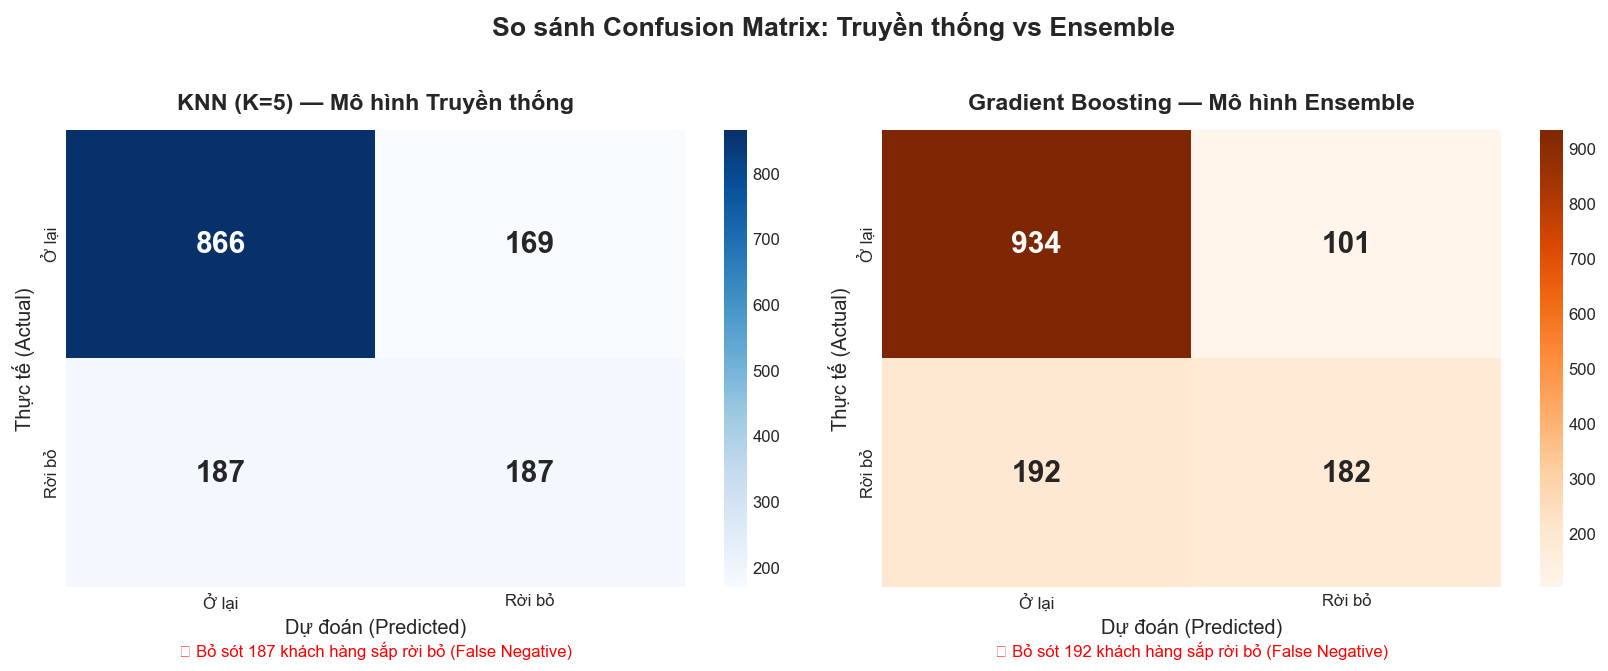


📊 KNN bỏ sót 187 khách hàng rời bỏ, Gradient Boosting bỏ sót 192 khách hàng.
→ Gradient Boosting giảm được -5 lượt bỏ sót so với KNN (-2.7% cải thiện).


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# === KNN ===
knn_cm = confusion_matrix(y_test, trained_models['KNN (K=5)']['y_pred'])
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            annot_kws={'size': 18, 'weight': 'bold'},
            xticklabels=['Ở lại', 'Rời bỏ'], yticklabels=['Ở lại', 'Rời bỏ'])
axes[0].set_title('KNN (K=5) — Mô hình Truyền thống', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Dự đoán (Predicted)', fontsize=12)
axes[0].set_ylabel('Thực tế (Actual)', fontsize=12)

# Add annotation
knn_fn = knn_cm[1][0]  # False Negatives
axes[0].text(0.5, -0.15, f'⚠ Bỏ sót {knn_fn} khách hàng sắp rời bỏ (False Negative)',
             transform=axes[0].transAxes, ha='center', fontsize=10, color='red')

# === Gradient Boosting ===
gb_cm = confusion_matrix(y_test, trained_models['Gradient Boosting']['y_pred'])
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            annot_kws={'size': 18, 'weight': 'bold'},
            xticklabels=['Ở lại', 'Rời bỏ'], yticklabels=['Ở lại', 'Rời bỏ'])
axes[1].set_title('Gradient Boosting — Mô hình Ensemble', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Dự đoán (Predicted)', fontsize=12)
axes[1].set_ylabel('Thực tế (Actual)', fontsize=12)

gb_fn = gb_cm[1][0]
axes[1].text(0.5, -0.15, f'⚠ Bỏ sót {gb_fn} khách hàng sắp rời bỏ (False Negative)',
             transform=axes[1].transAxes, ha='center', fontsize=10, color='red')

plt.suptitle('So sánh Confusion Matrix: Truyền thống vs Ensemble', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/confusion_matrix_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n📊 KNN bỏ sót {knn_fn} khách hàng rời bỏ, Gradient Boosting bỏ sót {gb_fn} khách hàng.')
print(f'→ Gradient Boosting giảm được {knn_fn - gb_fn} lượt bỏ sót so với KNN ({(knn_fn - gb_fn)/knn_fn*100:.1f}% cải thiện).')

## 5. Biểu đồ Bar Chart — So sánh các chỉ số

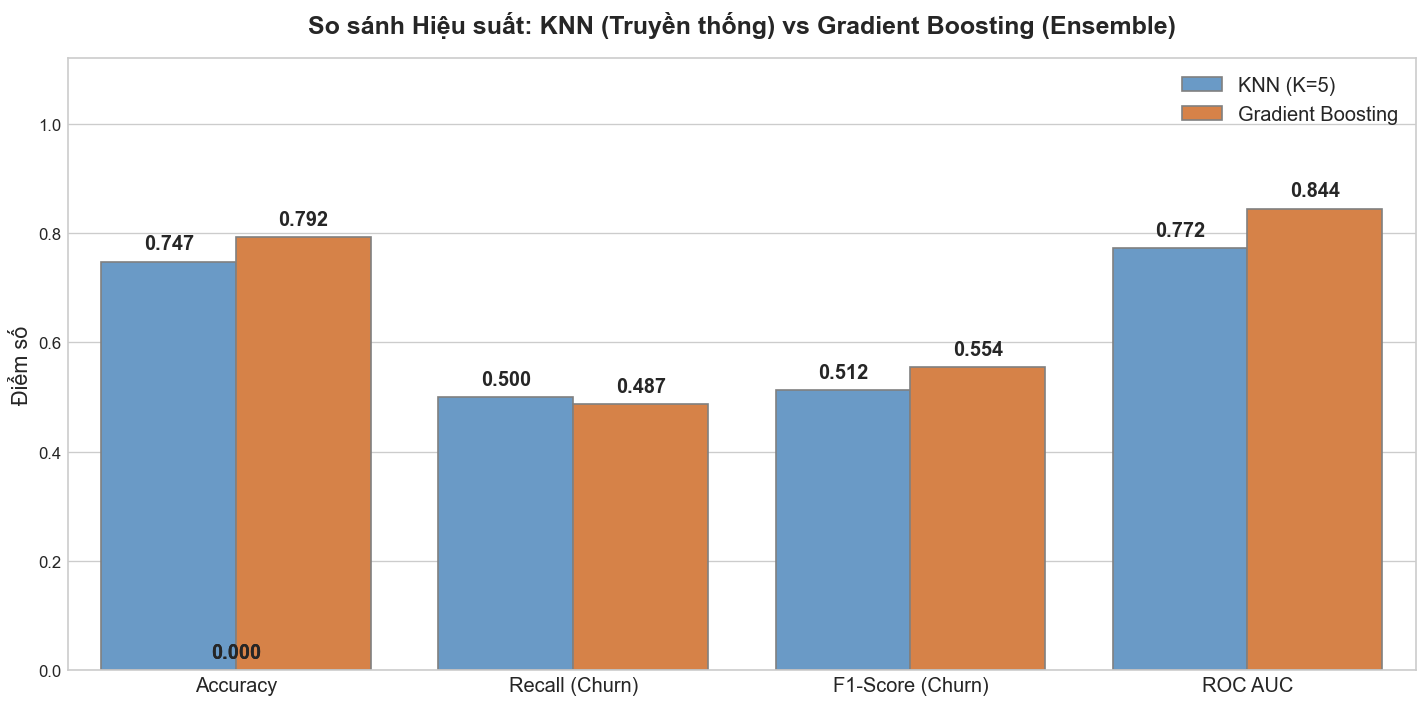

In [5]:
# Compare the two best models
compare_models = ['KNN (K=5)', 'Gradient Boosting']
df_compare = df_results[df_results['Model'].isin(compare_models)].copy()

metrics_to_plot = ['Accuracy', 'Recall (Churn)', 'F1-Score (Churn)', 'ROC AUC']
df_melted = df_compare.melt(id_vars='Model', value_vars=metrics_to_plot,
                             var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted,
                   palette=['#5B9BD5', '#ED7D31'], ax=ax, edgecolor='grey')

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

ax.set_title('So sánh Hiệu suất: KNN (Truyền thống) vs Gradient Boosting (Ensemble)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Điểm số', fontsize=13)
ax.set_xlabel('')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=12, loc='upper right')
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.savefig('../images/metrics_comparison_barchart.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. ROC Curve — Đường cong đánh giá mô hình

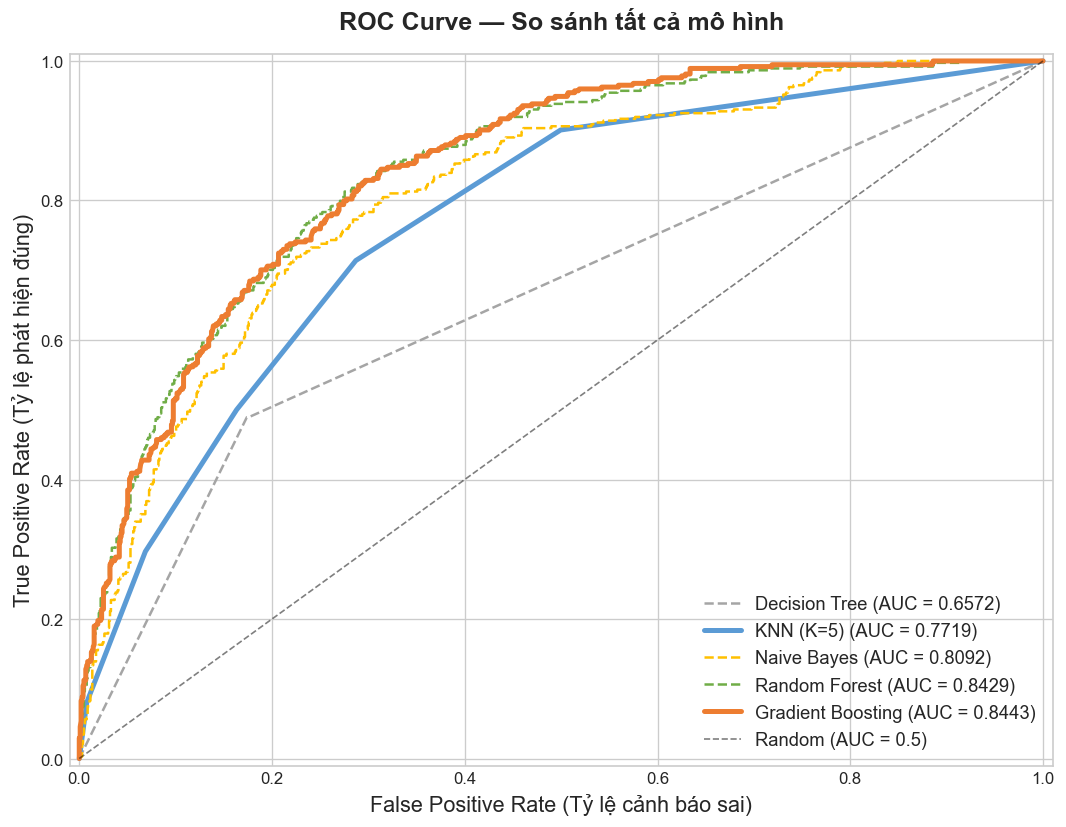


📌 AUC càng gần 1.0 càng tốt. Đường đứt nét chéo là mô hình đoán ngẫu nhiên (AUC=0.5).
→ Gradient Boosting có đường cong cao nhất, cho thấy khả năng phân loại vượt trội.


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = {'KNN (K=5)': '#5B9BD5', 'Gradient Boosting': '#ED7D31',
          'Decision Tree': '#A5A5A5', 'Naive Bayes': '#FFC000', 'Random Forest': '#70AD47'}

for name in models.keys():
    y_proba = trained_models[name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    
    # Bold lines for the two best models
    lw = 3 if name in compare_models else 1.5
    ls = '-' if name in compare_models else '--'
    
    ax.plot(fpr, tpr, color=colors[name], lw=lw, linestyle=ls,
            label=f'{name} (AUC = {auc_val:.4f})')

# Diagonal
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate (Tỷ lệ cảnh báo sai)', fontsize=13)
ax.set_ylabel('True Positive Rate (Tỷ lệ phát hiện đúng)', fontsize=13)
ax.set_title('ROC Curve — So sánh tất cả mô hình', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig('../images/roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n📌 AUC càng gần 1.0 càng tốt. Đường đứt nét chéo là mô hình đoán ngẫu nhiên (AUC=0.5).')
print('→ Gradient Boosting có đường cong cao nhất, cho thấy khả năng phân loại vượt trội.')

## 7. Thời gian huấn luyện (Training Time)

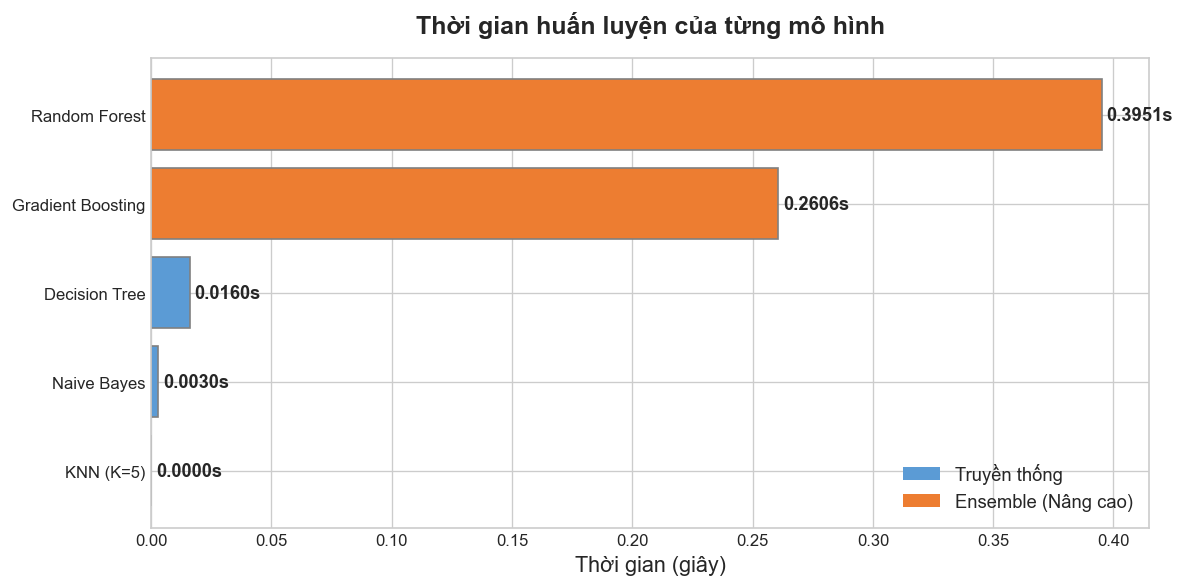


📌 Nhận xét: Mô hình Ensemble (Random Forest, Gradient Boosting) tốn nhiều thời gian hơn
   nhưng cho kết quả chính xác hơn đáng kể → Đánh đổi chấp nhận được trong thực tế.


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

time_data = df_results[['Model', 'Training Time (s)']].sort_values('Training Time (s)', ascending=True)
bar_colors = ['#5B9BD5' if m in ['Decision Tree', 'KNN (K=5)', 'Naive Bayes'] else '#ED7D31'
              for m in time_data['Model']]

bars = ax.barh(time_data['Model'], time_data['Training Time (s)'], color=bar_colors, edgecolor='grey')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}s', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Thời gian (giây)', fontsize=13)
ax.set_title('Thời gian huấn luyện của từng mô hình', fontsize=15, fontweight='bold', pad=15)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#5B9BD5', label='Truyền thống'),
                   Patch(facecolor='#ED7D31', label='Ensemble (Nâng cao)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../images/training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n📌 Nhận xét: Mô hình Ensemble (Random Forest, Gradient Boosting) tốn nhiều thời gian hơn')
print('   nhưng cho kết quả chính xác hơn đáng kể → Đánh đổi chấp nhận được trong thực tế.')

## 8. Kết luận Bước 4

### Nhận xét chính:

1. **Gradient Boosting** là mô hình có hiệu suất tổng thể tốt nhất với Accuracy và ROC AUC cao nhất.

2. **KNN (K=5)** là mô hình truyền thống tốt nhất, được chọn làm đại diện Baseline để so sánh.

3. **Recall (Churn)** — chỉ số quan trọng nhất trong bài toán Churn — cho thấy Gradient Boosting phát hiện khách hàng rời bỏ tốt hơn so với KNN.

4. **Thời gian huấn luyện:** Các mô hình Ensemble tốn thời gian hơn nhưng vẫn ở mức chấp nhận được (dưới vài giây), xứng đáng với mức cải thiện hiệu suất mang lại.

5. **ROC Curve** cho thấy rõ ràng các mô hình Ensemble (đường liền nét) luôn nằm phía trên các mô hình truyền thống (đường đứt nét), chứng minh khả năng phân loại vượt trội.

### Trade-off:
| | Mô hình truyền thống (KNN) | Mô hình nâng cao (Gradient Boosting) |
|---|---|---|
| Ưu điểm | Nhanh, đơn giản, dễ giải thích | Chính xác hơn, tổng quát hóa tốt hơn |
| Nhược điểm | Recall thấp, bỏ sót nhiều khách rời bỏ | Tốn thời gian hơn, khó giải thích hơn |

→ **Kết luận:** Trong bài toán Churn, việc bỏ sót khách hàng rời bỏ gây thiệt hại lớn hơn việc cảnh báo nhầm. Do đó, **Gradient Boosting là lựa chọn tối ưu**.